# Lorena's Bioprocess Model

This model aims to describe a growth system of Pseudomonas putida in different
set-ups. The model not only studies the microorganism’s growth dynamics
but also the consumption of a carbon source (substrate) and other nutrients
(chemical elements). Additionally, it examines the dynamics of gases that may
be used in the process, including both those in the gas phase of the system and
those dissolved in the liquid phase.

For further information, please check the [*BIOS_Pseudomonas_model.pdf*](misc/BIOS_Pseudomonas_model.pdf) document associated with this notebook in the *misc* folder.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Functions (Model Included)

In [3]:
# Function to export a dictionary of lists (e.g., y0_dict or params_dict) to CSV
def export_dict_to_csv(dictionary, filepath):
    df = pd.DataFrame.from_dict(dictionary, orient='index')
    df.columns = ['value']  # all values are lists with one element
    df.to_csv(filepath)

# Function to load a CSV back into a dictionary of lists
def load_csv_to_dict(filepath):
    df = pd.read_csv(filepath, index_col=0)
    return {k: [v] for k, v in df['value'].items()}

# Define the ODE system
def bioprocess_odes(t, y, p):
    Biomass, Sub, Ca, Cl, Co, Cu, Fe, Mg, Mo, Na, Zn, K, Ni, NH4, P, S, CO2_l, CO2_g, O2_l, O2_g, H, OH = y

    # Unpack parameters
    V_f = p["V_f"]
    V_s = p["V_s"]
    V_r = p["V_r"]
    V_l = p["V_l"]
    V_g = p["V_g"]
    V_b = p["V_b"]
    V_Gasin = p["V_Gasin"]
    V_offGas = p["V_offGas"]
    V_a = p["V_a"]
    Y_Sub = p["Y_Sub"]
    Y_Ca = p["Y_Ca"]
    Y_Cl = p["Y_Cl"]
    Y_Co = p["Y_Co"]
    Y_Cu = p["Y_Cu"]
    Y_Fe = p["Y_Fe"]
    Y_Mg = p["Y_Mg"]
    Y_Mo = p["Y_Mo"]
    Y_Na = p["Y_Na"]
    Y_Zn = p["Y_Zn"]
    Y_K = p["Y_K"]
    Y_Ni = p["Y_Ni"]
    Y_NH4 = p["Y_NH4"]
    Y_P = p["Y_P"]
    Y_CO2 = p["Y_CO2"]
    Y_O2 = p["Y_O2"]
    Y_H = p["Y_H"]
    Y_S = p["Y_S"]
    mu = p["mu"]
    CSub_f = p["CSub_f"]
    CCa_f = p["CCa_f"]
    CCl_f = p["CCl_f"]
    CCo_f = p["CCo_f"]
    CCu_f = p["CCu_f"]
    CFe_f = p["CFe_f"]
    CMg_f = p["CMg_f"]
    CMo_f = p["CMo_f"]
    CNa_f = p["CNa_f"]
    CNab = p["CNab"]
    CZn_f = p["CZn_f"]
    CK_f = p["CK_f"]
    CNi_f = p["CNi_f"]
    CNH4_f = p["CNH4_f"]
    CP_f = p["CP_f"]
    CS_f = p["CS_f"]
    CO2_Gasin = p["CO2_Gasin"]
    O2_Gasin = p["O2_Gasin"]
    CH_f = p["CH_f"]
    CH_a = p["CH_a"]
    COH_f = p["COH_f"]
    COH_b = p["COH_b"]
    CO2_sat = p["CO2_sat"]
    O2_sat = p["O2_sat"]
    K_L_a = p["K_L_a"]

    # Compute derivatives
    dBiomass_dt = mu * Biomass - (Biomass / V_l) * V_s
    dSub_dt = CSub_f * V_f - (Sub / V_r) * V_s - (1 / Y_Sub) * mu * Biomass
    dCa_dt = CCa_f * V_f - (Ca / V_l) * V_s - (1 / Y_Ca) * mu * Biomass
    dCl_dt = CCl_f * V_f - (Cl / V_l) * V_s - (1 / Y_Cl) * mu * Biomass
    dCo_dt = CCo_f * V_f - (Co / V_l) * V_s - (1 / Y_Co) * mu * Biomass
    dCu_dt = CCu_f * V_f - (Cu / V_l) * V_s - (1 / Y_Cu) * mu * Biomass
    dFe_dt = CFe_f * V_f - (Fe / V_l) * V_s - (1 / Y_Fe) * mu * Biomass
    dMg_dt = CMg_f * V_f - (Mg / V_l) * V_s - (1 / Y_Mg) * mu * Biomass
    dMo_dt = CMo_f * V_f - (Mo / V_l) * V_s - (1 / Y_Mo) * mu * Biomass
    dNa_dt = CNa_f * V_f + CNab * V_b - (Na / V_l) * V_s - (1 / Y_Na) * mu * Biomass
    dZn_dt = CZn_f * V_f - (Zn / V_l) * V_s - (1 / Y_Zn) * mu * Biomass
    dK_dt = CK_f * V_f - (K / V_l) * V_s - (1 / Y_K) * mu * Biomass
    dNi_dt = CNi_f * V_f - (Ni / V_l) * V_s - (1 / Y_Ni) * mu * Biomass
    dNH4_dt = CNH4_f * V_f - (NH4 / V_l) * V_s - (1 / Y_NH4) * mu * Biomass
    dP_dt = CP_f * V_f - (P / V_l) * V_s - (1 / Y_P) * mu * Biomass
    dS_dt = CS_f * V_f - (S / V_l) * V_s - Y_S * mu * Biomass
    dCO2l_dt = K_L_a * (CO2_sat - CO2_l) * V_l + (1 / Y_CO2) * mu * Biomass
    dCO2g_dt = CO2_Gasin * V_Gasin - K_L_a * (CO2_sat - CO2_l) * V_l - (CO2_g / V_g) * V_offGas
    dO2l_dt = K_L_a * (O2_sat - O2_l) * V_l - (1 / Y_O2) * mu * Biomass
    dO2g_dt = O2_Gasin * V_Gasin - K_L_a * (O2_sat - O2_l) * V_l - (O2_g / V_g) * V_offGas
    dH_dt = CH_f * V_f + CH_a * V_a - (H / V_l) * V_s + (1 / Y_H) * mu * Biomass
    dOH_dt = COH_f * V_f + COH_b * V_b - (OH / V_l) * V_s

    return [
        dBiomass_dt, dSub_dt, dCa_dt, dCl_dt, dCo_dt, dCu_dt, dFe_dt, dMg_dt, dMo_dt,
        dNa_dt, dZn_dt, dK_dt, dNi_dt, dNH4_dt, dP_dt, dS_dt,
        dCO2l_dt, dCO2g_dt, dO2l_dt, dO2g_dt, dH_dt, dOH_dt
    ]


In [4]:

# Adjusted simulation using dictionaries of lists for y0 and parameters

# Initial condition dictionary with values as lists
y0_dict = {
    "Biomass": [0.1], "Sub": [10], "Ca": [0.05], "Cl": [0.05], "Co": [0.05], "Cu": [0.05],
    "Fe": [0.05], "Mg": [0.05], "Mo": [0.05], "Na": [0.1], "Zn": [0.05], "K": [0.05],
    "Ni": [0.05], "NH4": [0.05], "P": [0.05], "S": [0.05], "CO2_l": [0.1], "CO2_g": [0.1],
    "O2_l": [0.2], "O2_g": [0.2], "H": [0.05], "OH": [0.05]
}

# Parameters dictionary with values as lists
params_dict = {
    "V_f": [0.01], "V_s": [0.005], "V_r": [1.0], "V_l": [1.0], "V_g": [1.0], "V_b": [0.002],
    "V_Gasin": [0.003], "V_offGas": [0.001], "V_a": [0.001],
    "Y_Sub": [0.5], "Y_Ca": [0.4], "Y_Cl": [0.4], "Y_Co": [0.4], "Y_Cu": [0.4], "Y_Fe": [0.4],
    "Y_Mg": [0.4], "Y_Mo": [0.4], "Y_Na": [0.4], "Y_Zn": [0.4], "Y_K": [0.4], "Y_Ni": [0.4],
    "Y_NH4": [0.4], "Y_P": [0.4], "Y_CO2": [0.3], "Y_O2": [0.2], "Y_H": [0.5], "Y_S": [0.05],
    "CSub_f": [5.0], "CCa_f": [1.0], "CCl_f": [1.0], "CCo_f": [1.0], "CCu_f": [1.0],
    "CFe_f": [1.0], "CMg_f": [1.0], "CMo_f": [1.0], "CNa_f": [1.0], "CNab": [0.5],
    "CZn_f": [1.0], "CK_f": [1.0], "CNi_f": [1.0], "CNH4_f": [1.0], "CP_f": [1.0],
    "CS_f": [1.0], "CO2_Gasin": [0.05], "O2_Gasin": [0.05], "CH_f": [0.1], "CH_a": [0.05],
    "COH_f": [0.05], "COH_b": [0.05], "CO2_sat": [0.3], "O2_sat": [0.2], "K_L_a": [50.0],
    "mu": [0.2]
}

# Convert to flat vectors
y0 = [v[0] for v in y0_dict.values()]
params = {k: v[0] for k, v in params_dict.items()}

# export
export_dict_to_csv(y0_dict, "playground_folders/inputs/y0_dict.csv")
export_dict_to_csv(params_dict, "playground_folders/inputs/params_dict.csv")

# load
loaded_y0_dict = load_csv_to_dict("playground_folders/inputs/y0_dict.csv")
loaded_params_dict = load_csv_to_dict("playground_folders/inputs/params_dict.csv")


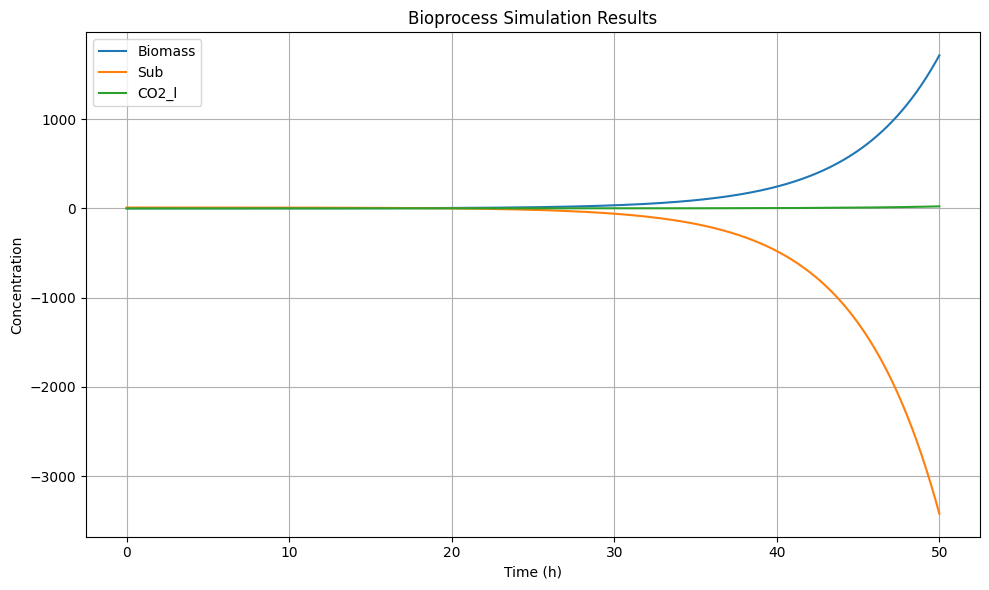

In [5]:
# Time span and evaluation points
t_span = (0, 50)
t_eval = np.linspace(*t_span, 500)

# Solve ODEs
sol = solve_ivp(lambda t, y: bioprocess_odes(t, y, params), t_span, y0, t_eval=t_eval, method='RK45')

# Format results into DataFrame
df = pd.DataFrame(sol.y.T, columns=list(y0_dict.keys()))
df.insert(0, "Time", sol.t)

# Plot example: Biomass, Sub, CO2_l
plt.figure(figsize=(10, 6))
for var in ["Biomass", "Sub", "CO2_l"]:
    plt.plot(df["Time"], df[var], label=var)
plt.xlabel("Time (h)")
plt.ylabel("Concentration")
plt.title("Bioprocess Simulation Results")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# Function to export dataframe to CSV and save plot of selected variables
def export_simulation_results(df, variables, output_dir="playground_folders/outputs", prefix="run1"):
    os.makedirs(output_dir, exist_ok=True)

    # Save CSV
    csv_path = os.path.join(output_dir, f"{prefix}_results.csv")
    df.to_csv(csv_path, index=False)

    # Plot selected variables
    plt.figure(figsize=(10, 6))
    for var in variables:
        if var in df.columns:
            plt.plot(df["Time"], df[var], label=var)
    plt.xlabel("Time (h)")
    plt.ylabel("Concentration")
    plt.title("Bioprocess Dynamics")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save plot
    png_path = os.path.join(output_dir, f"{prefix}_plot.png")
    plt.savefig(png_path)
    plt.close()

    return csv_path, png_path

# Example usage
selected_vars = ["Biomass", "Sub", "CO2_l"]
csv_file, png_file = export_simulation_results(df, selected_vars)

(csv_file, png_file)  # Display output file paths


('playground_folders/outputs/run1_results.csv',
 'playground_folders/outputs/run1_plot.png')